# Null Benchmarking

This notebook regenerates the thesis-facing null benchmark panels from thesis-local curated files only. The outputs correspond to Figure 5 panels a-c and compare observed result counts with mutation-randomised null ranges.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'outputs' / 'thesis').exists():
    ROOT = ROOT.parent

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
})

THESIS_DIR = ROOT / 'outputs/thesis/05_null_bootstrap_validation'
DATA_DIR = THESIS_DIR / 'data'
FIG_DIR = THESIS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = DATA_DIR / 'null_bootstrap_proper_vs_null_summary.csv'
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing required input: {SUMMARY_PATH}')

summary = pd.read_csv(SUMMARY_PATH)
summary


,metric,analysis_type,proper_count,null_mean,null_min,null_max,null_median,null_sd,null_n,p_null_ge_proper
0,validation_n_p_le_0.05,Validation label-association tests,0.0,0.4,0.0,3.0,0.0,0.966092,10,1.0
1,validation_group_tests_n_p_le_0.05,Validation group tests,2.0,0.5,0.0,2.0,0.0,0.707107,10,0.1
2,validation_group_tests_mb_adjusted_n_p_le_0.05,Mutation-burden-adjusted group tests,3.0,0.3,0.0,2.0,0.0,0.674949,10,0.0
3,deseq_significant_genes,DESeq2 significant genes,0.0,0.0,0.0,0.0,0.0,0.000000,10,1.0
4,limma_significant_genes,limma-voom significant genes,4.0,0.4,0.0,2.0,0.0,0.699206,10,0.0
5,fgsea_stat_significant_pathways,FGSEA-stat significant pathways,29.0,19.3,7.0,30.0,20.5,7.379401,10,0.1
6,fgsea_fc_significant_pathways,FGSEA logFC × −log10(p) significant pathways,0.0,0.5,0.0,2.0,0.0,0.707107,10,1.0


## 1) Clinical Association Tests

Clinical null benchmarking compares observed clinical-test counts with mutation-randomised null replicates. Binary label tests remain close to null expectation, while mutation-burden-adjusted continuous FOXA2 score tests show clearer separation from the null background.


/tmp/ipykernel_269607/3326024394.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])


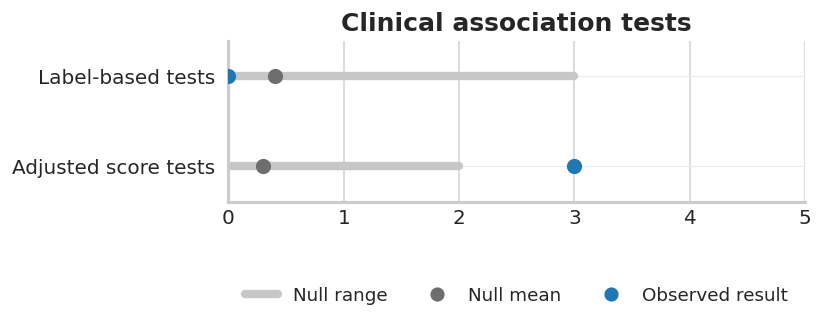

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/05_null_bootstrap_validation/figures/01_null_benchmark_clinical_tests.png


PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/05_null_bootstrap_validation/figures/01_null_benchmark_clinical_tests.png')

In [2]:
def save_and_show(fig: plt.Figure, path: Path) -> Path:
    fig.savefig(path, dpi=300, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    print('Saved:', path)
    return path


def make_null_benchmark_panel(metrics, labels, title, xlim, xticks, filename):
    rows = []
    for metric, label in zip(metrics, labels):
        row = summary.loc[summary['metric'].eq(metric)].iloc[0]
        rows.append({
            'label': label,
            'observed': row['proper_count'],
            'null_mean': row['null_mean'],
            'null_min': row['null_min'],
            'null_max': row['null_max'],
        })
    plot_df = pd.DataFrame(rows).iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(6.2, 1.75))
    ax.hlines(
        y,
        plot_df['null_min'],
        plot_df['null_max'],
        color='#C7C7C7',
        linewidth=5.0,
        zorder=1,
        capstyle='round',
    )
    ax.scatter(plot_df['null_mean'], y, color='#6E6E6E', s=58, zorder=3)
    ax.scatter(plot_df['observed'], y, color='#1f77b4', s=58, zorder=4)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['label'])
    ax.set_xlim(*xlim)
    ax.set_ylim(-0.40, len(plot_df) - 0.60)
    ax.set_xticks(xticks)
    ax.set_xlabel('')
    ax.set_title(title, pad=6)
    ax.grid(axis='x', color='#D6D6D6', linewidth=1.0)
    ax.grid(axis='y', color='#ECECEC', linewidth=0.7)
    ax.tick_params(axis='y', length=0, pad=8)
    ax.tick_params(axis='x', length=0)

    handles = [
        Line2D([0], [0], color='#C7C7C7', lw=5.0, solid_capstyle='round', label='Null range'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#6E6E6E', markeredgecolor='#6E6E6E', markersize=7.5, label='Null mean'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#1f77b4', markeredgecolor='#1f77b4', markersize=7.5, label='Observed result'),
    ]
    ax.legend(handles=handles, frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.42), columnspacing=1.8, handlelength=1.8)
    sns.despine(ax=ax, left=False, bottom=False)
    fig.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])
    return save_and_show(fig, FIG_DIR / filename)


make_null_benchmark_panel(
    ['validation_n_p_le_0.05', 'validation_group_tests_mb_adjusted_n_p_le_0.05'],
    ['Label-based tests', 'Adjusted score tests'],
    'Clinical association tests',
    (0, 5),
    np.arange(0, 6, 1),
    '01_null_benchmark_clinical_tests.png',
)


## 2) Genes

At the gene level, DESeq2 remains null-like, while limma-voom gives the clearest observed separation from the mutation-randomised background.


/tmp/ipykernel_269607/3326024394.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])


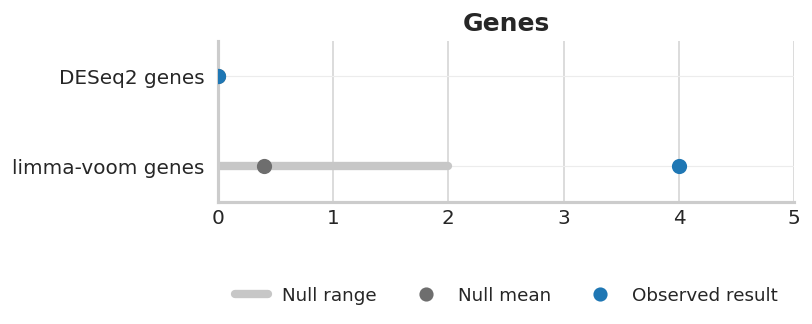

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/05_null_bootstrap_validation/figures/02_null_benchmark_genes.png


PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/05_null_bootstrap_validation/figures/02_null_benchmark_genes.png')

In [3]:
make_null_benchmark_panel(
    ['deseq_significant_genes', 'limma_significant_genes'],
    ['DESeq2 genes', 'limma-voom genes'],
    'Genes',
    (0, 5),
    np.arange(0, 6, 1),
    '02_null_benchmark_genes.png',
)


## 3) Pathways

Pathway-level evidence is more borderline. FGSEA-stat pathways are elevated in the observed analysis but overlap the upper null range, while FGSEA logFC-ranked pathways do not show enrichment above null expectation.


/tmp/ipykernel_269607/3326024394.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])


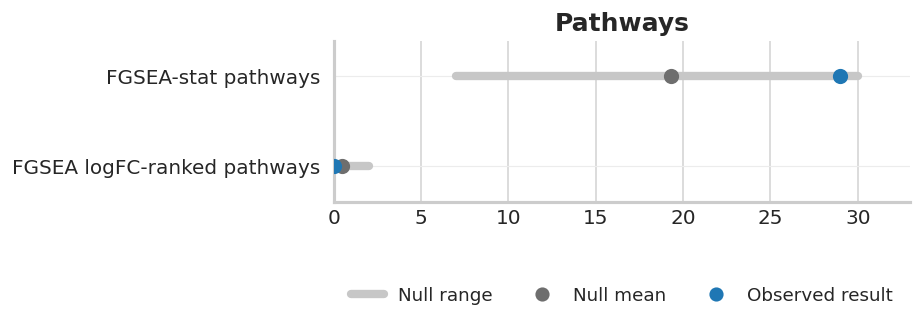

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/05_null_bootstrap_validation/figures/03_null_benchmark_pathways.png


PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/05_null_bootstrap_validation/figures/03_null_benchmark_pathways.png')

In [4]:
make_null_benchmark_panel(
    ['fgsea_stat_significant_pathways', 'fgsea_fc_significant_pathways'],
    ['FGSEA-stat pathways', 'FGSEA logFC-ranked pathways'],
    'Pathways',
    (0, 33),
    np.arange(0, 31, 5),
    '03_null_benchmark_pathways.png',
)
